In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]


In [8]:
# missing data

from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["age"]] = imp_freq.fit_transform(titanic[["age"]])

In [9]:
# encode

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [10]:
X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [11]:
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


In [12]:
# Decision Tree Model - no pruning

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7761194029850746


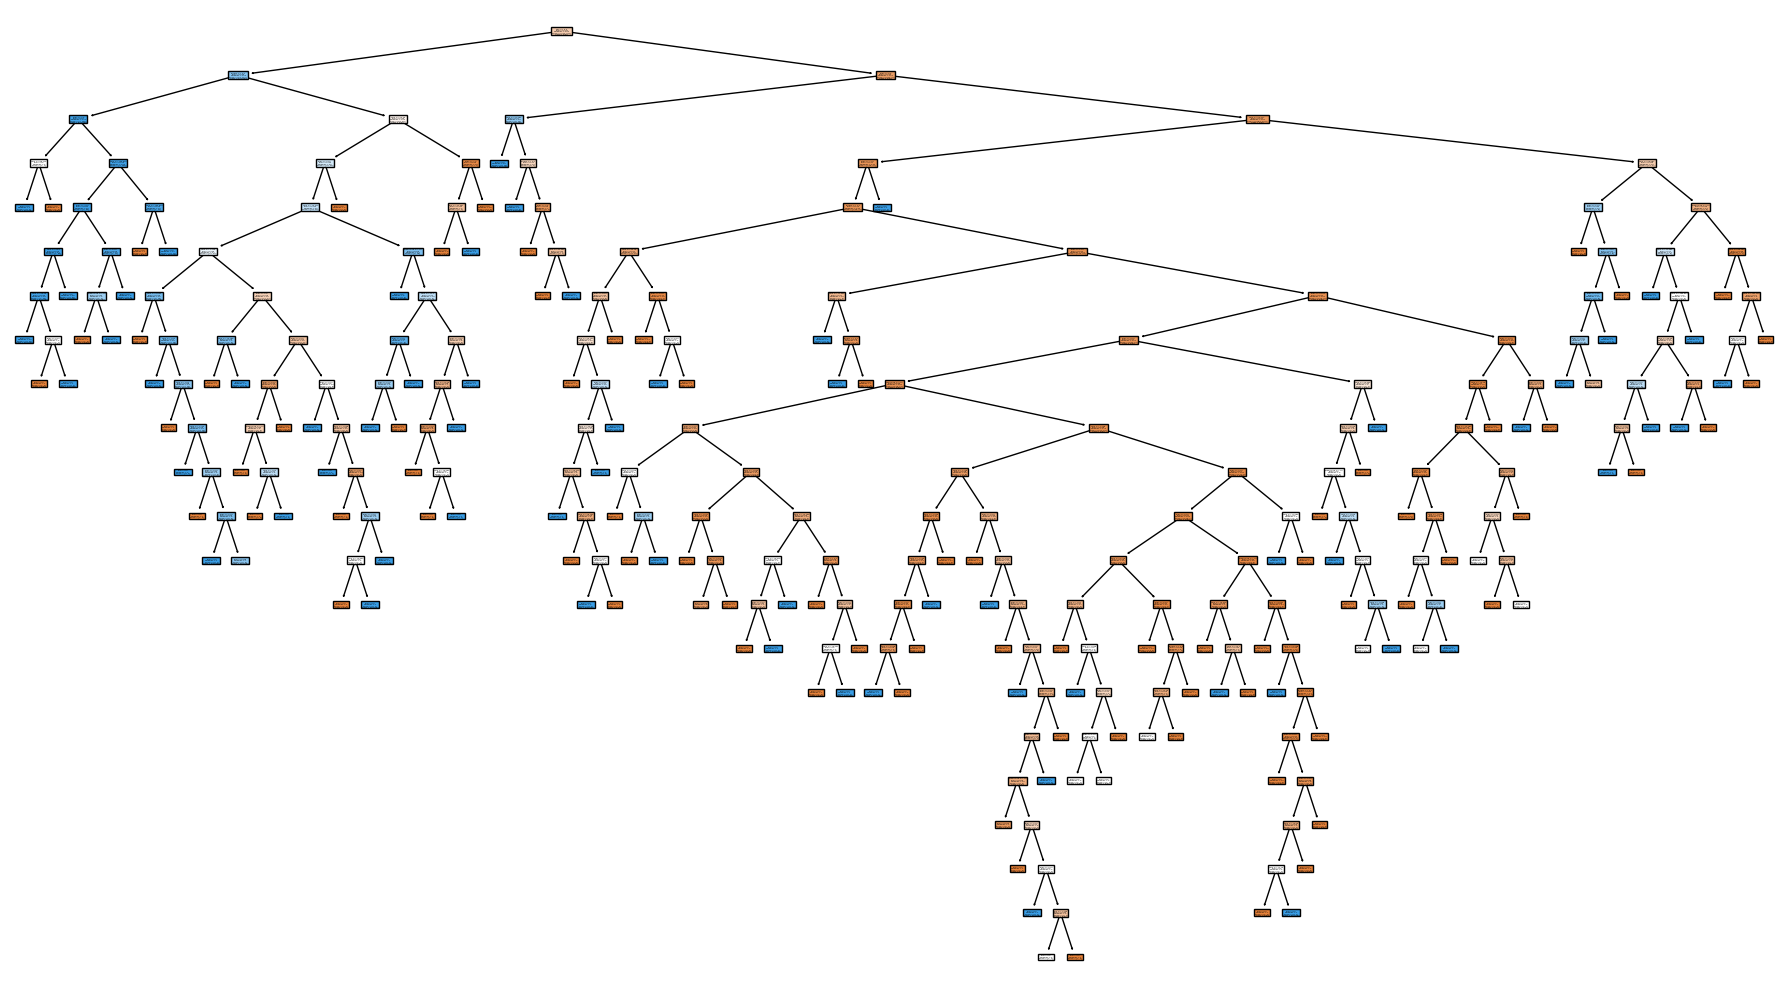

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize= (18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
)

plt.tight_layout()
plt.show()

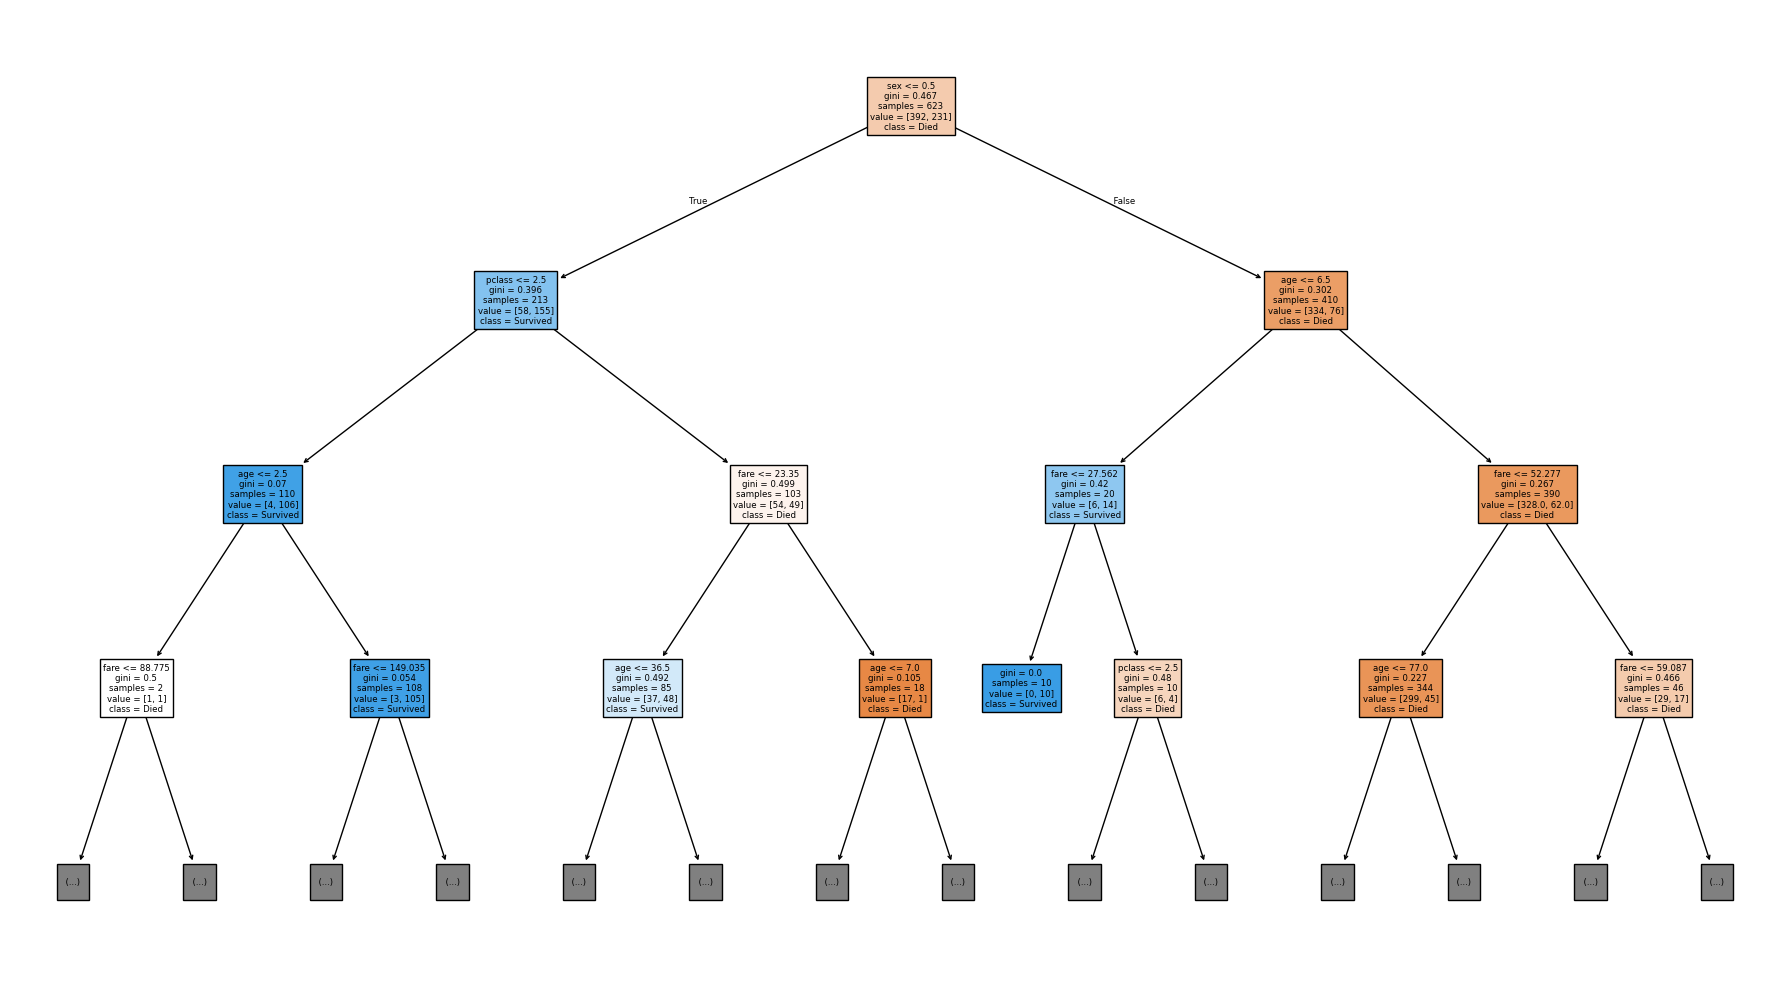

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize= (18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth = 3
)

plt.tight_layout()
plt.show()

#Decision tree with pre-pruning


for depth 2, accuracy : 0.7723880597014925
for depth 3, accuracy : 0.8059701492537313
for depth 4, accuracy : 0.8246268656716418


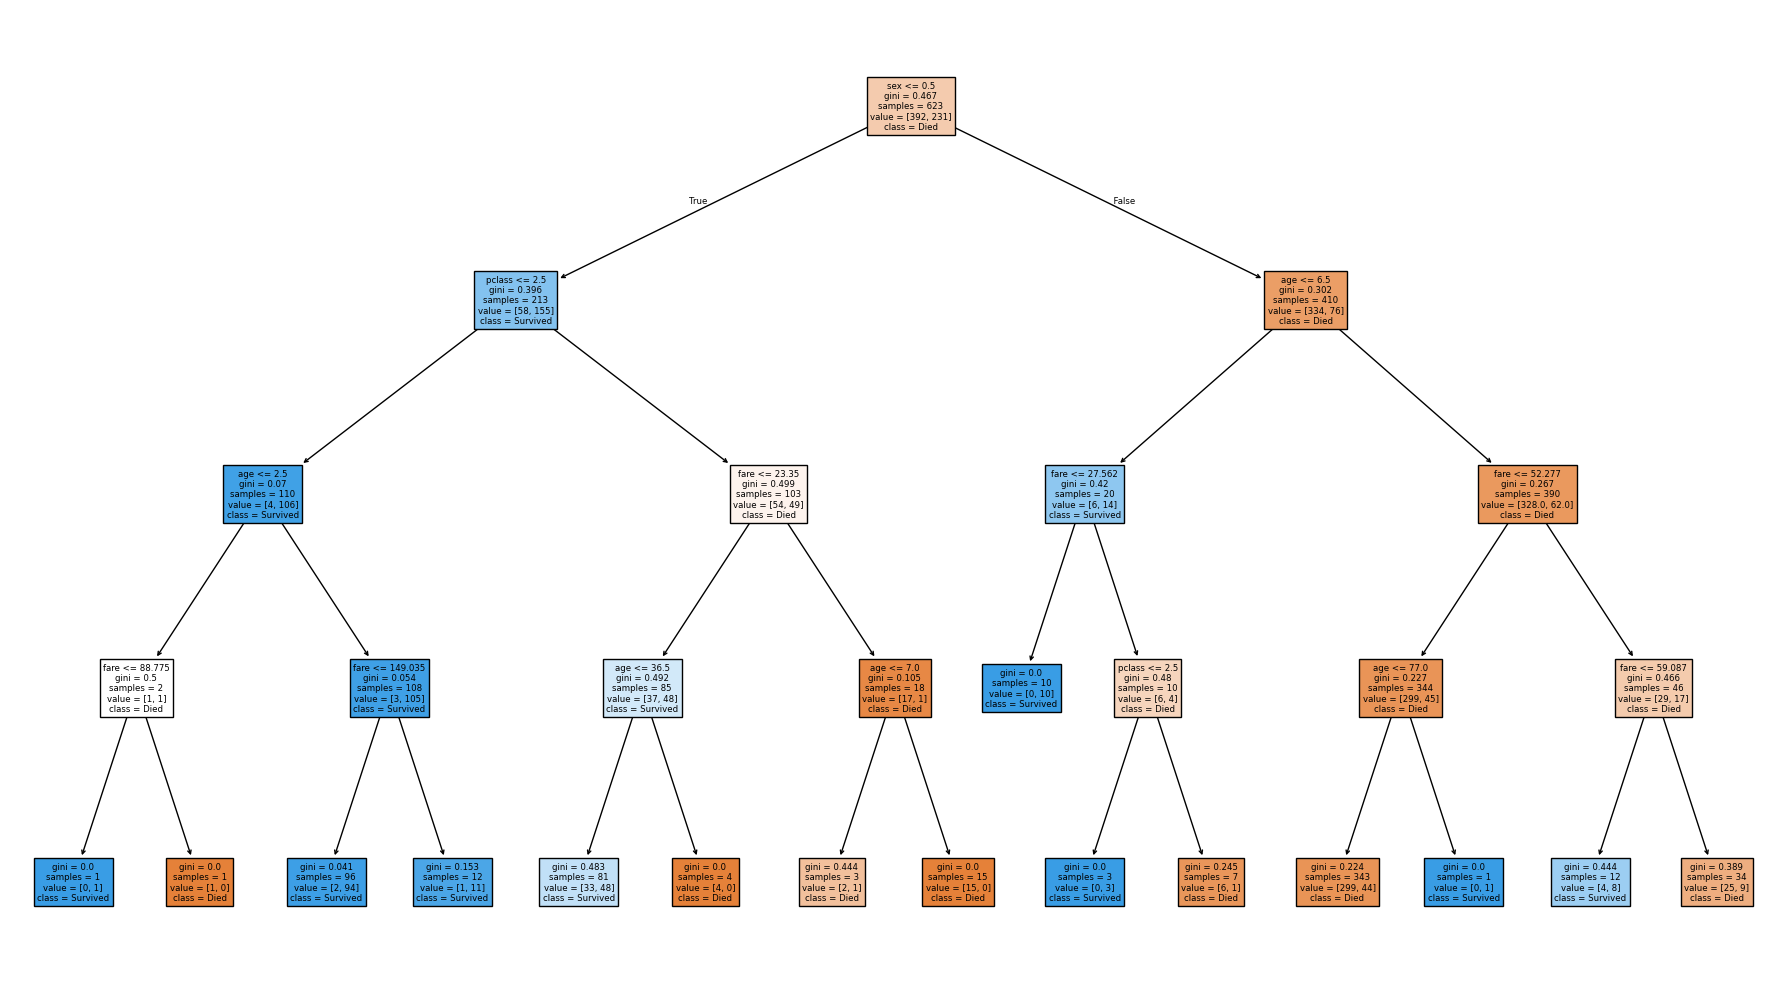

for depth 5, accuracy : 0.7947761194029851
for depth 6, accuracy : 0.7873134328358209
for depth 7, accuracy : 0.7835820895522388
for depth 8, accuracy : 0.7985074626865671
for depth 9, accuracy : 0.7761194029850746
for depth 10, accuracy : 0.7873134328358209


In [28]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth= depth)
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    print(f"for depth {depth}, accuracy : {acc}")

    if depth==4:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

for sample split=5, accuracy=0.8246268656716418
for sample split=10, accuracy=0.8246268656716418


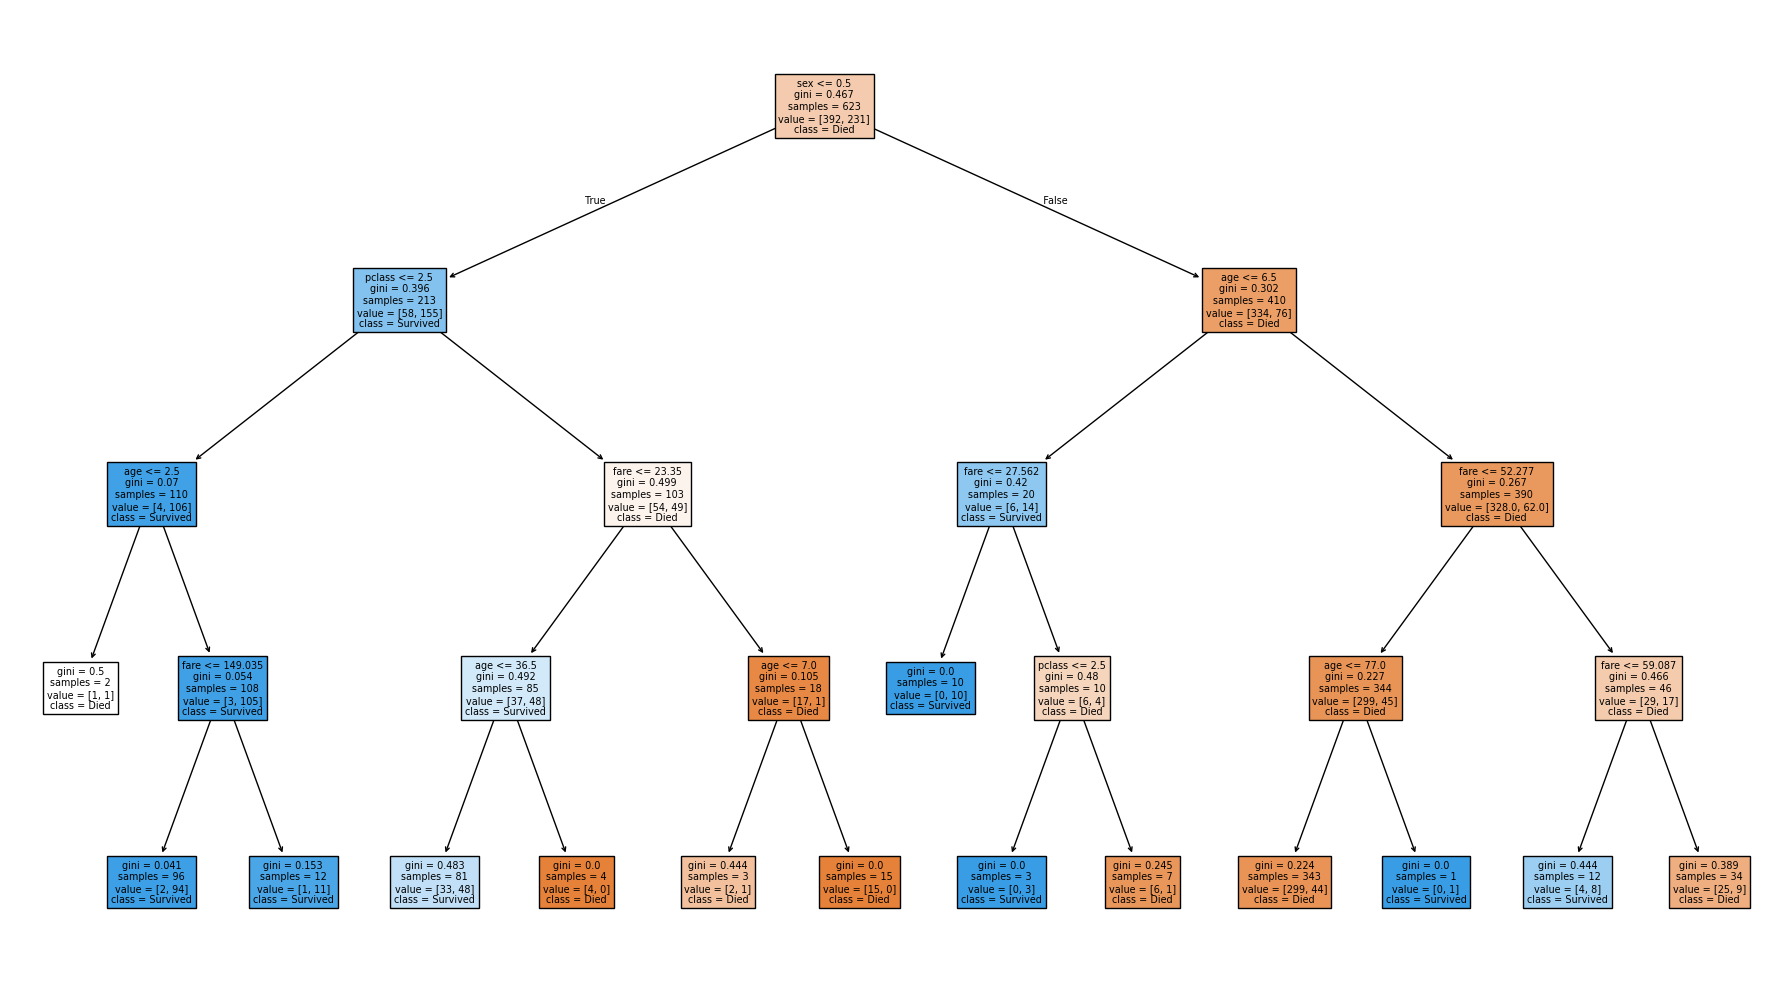

for sample split=15, accuracy=0.8171641791044776
for sample split=20, accuracy=0.8171641791044776
for sample split=25, accuracy=0.8208955223880597
for sample split=30, accuracy=0.8208955223880597


In [31]:
min_splits = [5, 10, 15, 20, 25, 30]

for split in min_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

#Decision Tree with post-pruning

In [32]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None
